# 定理23　諸行無常定理 — 数値で見る例

> **この notebook の位置づけ。** 数値シミュレーション（説明用のトイ例）で、証明ではありません。
> Lean で確かめた範囲は最後の「Lean との対応」に書きます。原文の主張・この例が見せること・仏教的な読み（解釈）は別の見出しに分けます。
> 定理23は四法印の最初（**諸行無常**）にあたります。**仏教語の思想的な解釈と、形式化された数理結論は別物** として読んでください。

## 1. 定理23は何を言っているのか

### 原文の主張

**第一部（条件23-A：生存＝持続的厳密散逸）。** 体・すべての思考の層・環境をひとまとめにした **完全状態** $z(t)$ があり、その **一般化総エントロピー** $\mathcal S(z)$（定理15の $S_{\mathrm{gen}}$。「散らかり度」）は **状態だけで決まる量** です。散逸（散らかり度の生成率）$\Pi_{\mathrm{gen}}(s)\ge0$ について、

$$
\int_{t_1}^{t_2}\Pi_{\mathrm{gen}}(s)\,ds>0\ \Longrightarrow\ z(t_2)\neq z(t_1)\qquad(23.1)
$$

（条件23-A：$t_2>t_1$ のすべての区間で $\int\Pi>0$）。**生きている限り、完全状態は二度と同じにならない**、という **非再帰** です。

**証明の心（背理法一発）。** もし $z(t_2)=z(t_1)$ なら、状態だけで決まる量 $\mathcal S$ も同じ値のはず。しかし差は $\int\Pi>0$ で **正**——矛盾。

**第二部（条件23-B：無限・非Zeno・非終端の包摂更新）。** 空未満では、**段階 TCZ は有限段で固定しません**。

$$
\mathrm{TCZ}^{\mathrm{cl}}_{n+1}\neq\mathrm{TCZ}^{\mathrm{cl}}_n\qquad(\text{すべての段 }n)\qquad(23.2)
$$

条件23-B は、新しい情報 $v_n$ が **無限に** 来て、各段のしきい値を満たし（定理22）、段の間隔が潰れない（**非 Zeno**）ことです。

### 原文の但し書き（誤解を封じる）

* 「毎瞬すべてがグチャグチャに変わる」ではありません。制御の方策 $\pi_c$ は関数なので、同じ関数のまま働き続けられる。変わり続けるのは **状態** です。正確な結論は「ホメオスタシスの閉ループには **永久的な作動終了時刻がない**」。
* 空に至っても、体の物理的無常は止まりません。止まりうるのは「さらなる高次の屋根への相対的な更新」だけです。
* $\Pi\ge0$ **だけでは**、平衡や周期回帰を排除できません（原文「常に変化の正確な意味」）。(A) のケース Π=0 がそれです。

### 記号とコード変数の対応

| 原文の記号 | 意味 | このコードでは |
| --- | --- | --- |
| 完全状態 $z=(\theta,e)$ | 円周 $\theta\in[0,2\pi)$ と実数 $e$。$\theta$ は周期 $2\pi$ で回り、$\mathcal S(z)=e$ | `orbit` が返す `(theta, e)` |
| 散逸 $\Pi$ | $\mathcal S$ は散逸でだけ増える（$e=\Pi t$） | `Pi`（0 と 0.05） |
| 段階 $n$ の地形 $\tilde V_n=\tfrac c2(x-x_n^*)^2$ | 谷の中心 $x_n^*$、段間距離 $\delta$、しきい値 $\theta$ | `c, delta, theta` |
| 切替時刻 $t_n=\sum T_n$ | 段 $n$ の継続時間の和 | `tn_ok, tn_zeno` |

## 2. なぜこれが「定理23の例」と言えるのか

3つの小さな例を、定理の3つの要素に対応させます。

* **(A) 非再帰。** 完全状態を「回る要素 $\theta$（周期 $2\pi$）＋ 散逸でだけ増える量 $e=\Pi t$」とします。
  * **$\Pi\equiv0$（条件23-A なし）：** $e$ は $0$ のまま。$t=2\pi$ で $\theta$ が一周して **元に戻る**（再帰）。**$\Pi\ge0$ だけでは非再帰は出ない** ことの例です。
  * **$\Pi=0.05>0$（条件23-A あり）：** どの $t_2>t_1$ でも $e$ が増えているので $z(t_2)\neq z(t_1)$。定理の結論が見える例です。
* **(B) 段階 TCZ の不固定。** 段 $n$ の地形 $\tilde V_n=\tfrac c2(x-x_n^*)^2$（谷 $x_n^*$）、次の段の谷は距離 $\delta$ だけ離れた位置。しきい値 $\theta$ のとき $\mathrm{TCZ}_{n+1}=\{\tilde V_{n+1}\le\theta\}$ は、次段の谷を中心とする区間です。前段の谷 $x_n^*$ がその中に入るかは、$\dfrac{c\delta^2}2\le\theta$ かどうかで決まります。
* **(C) 非 Zeno。** 段の継続時間 $T_n=1$ なら切替時刻 $t_n=\sum T_n\to\infty$（非 Zeno）。$T_n=2^{-n}$ なら $\sum T_n=1$ で **有限時刻に集積**（Zeno）。条件23-B の「段の間隔が潰れない」が必要なわけです。

## 3. 3つの計算

In [1]:
# %% 準備
import numpy as np
import matplotlib.pyplot as plt
import logging; logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)  # フォント警告を抑制
try:
    import japanize_matplotlib  # Colab: !pip -q install japanize-matplotlib
except Exception:
    plt.rcParams["font.family"] = ["Noto Sans CJK JP", "IPAexGothic", "sans-serif"]

# --- (A) ---
t = np.linspace(0, 4 * np.pi, 4001)
def orbit(Pi):
    theta = t % (2 * np.pi); e = Pi * t
    return theta, e
circ = lambda a, b: np.abs((a - b + np.pi) % (2 * np.pi) - np.pi)
def min_return_dist(Pi, t1_index=0, min_gap=0.5):
    th, e = orbit(Pi)
    mask = t - t[t1_index] > min_gap
    return np.sqrt(circ(th[mask], th[t1_index])**2 + (e[mask] - e[t1_index])**2).min()
d_noPi, d_Pi = min_return_dist(0.0), min_return_dist(0.05)

# --- (B) ---
c, delta = 1.0, 1.0
def in_TCZ_next(theta):                          # x_n* ∈ TCZ_{n+1}? ⇔ cδ²/2 ≤ θ
    return c * delta**2 / 2 <= theta
thetas = np.linspace(0, 1, 101)
stall = np.array([in_TCZ_next(th) for th in thetas])
theta_crit = c * delta**2 / 2

# --- (C) ---
n = np.arange(1, 41)
tn_ok, tn_zeno = np.cumsum(np.ones(40)), np.cumsum(2.0 ** -n)

* **(A)** `min_return_dist(Pi)` は、$t_1=0$ から $0.5$ 以上離れた時刻 $t_2$ での $\|z(t_2)-z(0)\|$（円周上の距離と $e$ の差の合成）の最小値。再帰するなら $0$ に近づきます。
* **(B)** `in_TCZ_next(theta)` は「前段の谷が次段の TCZ に入るか」$\Longleftrightarrow\ \dfrac{c\delta^2}2\le\theta$（$c=\delta=1$ なので $\theta\ge0.5$）。
* **(C)** 2通りの切替時刻の累積和。

## 4. 図を読む

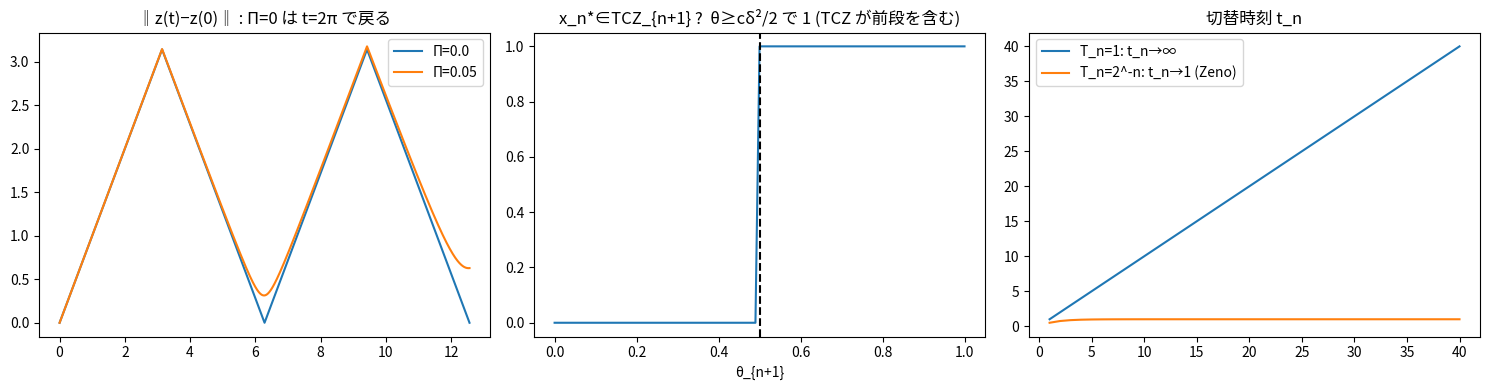

In [2]:
# %% 可視化
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for Pi in (0.0, 0.05):
    th, e = orbit(Pi); ax[0].plot(t, np.sqrt(circ(th, 0)**2 + e**2), label=f"Π={Pi}")
ax[0].set_title("‖z(t)−z(0)‖ : Π=0 は t=2π で戻る"); ax[0].legend()
ax[1].plot(thetas, stall.astype(int)); ax[1].axvline(theta_crit, ls="--", c="k")
ax[1].set_title("x_n*∈TCZ_{n+1} ?  θ≥cδ²/2 で 1 (TCZ が前段を含む)"); ax[1].set_xlabel("θ_{n+1}")
ax[2].plot(n, tn_ok, label="T_n=1: t_n→∞"); ax[2].plot(n, tn_zeno, label="T_n=2^-n: t_n→1 (Zeno)"); ax[2].legend(); ax[2].set_title("切替時刻 t_n")
plt.tight_layout(); plt.show()

### 左：$\|z(t)-z(0)\|$

横軸は時間（$0\sim4\pi$）、縦軸は出発点からの距離。
* **青（$\Pi=0$）：** 三角波のように $0\to\pi\to0\to\pi\to0$ と動き、**$t=2\pi$（約 6.28）と $t=4\pi$ で $0$ に戻ります**。完全状態が **元に戻って**（再帰）います。
* **橙（$\Pi=0.05$）：** 同じ三角波ですが、**$t=2\pi$ でも $0$ に戻らず約 $0.31$**（$=0.05\times2\pi$）、$t=4\pi$ では約 $0.63$。$e=\Pi t$ が増えているので、**決して同じ状態に戻りません**。

橙のほうが定理23第一部の結論です：$\int\Pi>0\Rightarrow z(t_2)\neq z(t_1)$。青は「$\Pi\ge0$ だけでは排除できない周期回帰」の例です。

### 中：前段の谷は次段の TCZ に入るか

横軸が次段のしきい値 $\theta_{n+1}$、縦軸が真偽（0 or 1）。破線が $\theta=c\delta^2/2=0.5$。
**$\theta<0.5$ では 0（入らない）、$\theta\ge0.5$ では 1（入る）**。階段状に切り替わります。

* $\theta<0.5$：次段の TCZ は、前段の谷を **含みません**。前段で落ち着いていた状態は次段の居心地ゾーンの外に出てしまうので、**動き直す必要がある**（新しい谷へ向かう）。
* $\theta\ge0.5$：次段の TCZ が前段の谷を **すでに含んで** います。状態は動かなくてもすでに次段の居心地ゾーンの中にいる。
  ただし、**TCZ という集合そのものは、どちらの場合も $\mathrm{TCZ}_{n+1}\neq\mathrm{TCZ}_n$ です**（谷の中心が違うので別の区間）。(23.2) は集合が違うことを述べ、状態が必ず動くとは述べていません。

### 右：切替時刻 $t_n$

* **青（$T_n=1$）：** $t_n=n$ の直線。**$n=40$ で $40$**。無限に伸びます（非 Zeno）。
* **橙（$T_n=2^{-n}$）：** すぐ $1$ に張りつき、**$n=40$ でも約 $1$**。**有限時刻 $t=1$ に集積**（Zeno）。この場合、$t=1$ より後に「次の段」がなく、階段が有限時間で止まってしまいます。条件23-B はこれを排除します。

## 5. 数値確認

In [3]:
# %% 数値確認
print(f"(A) 再帰距離: Π=0 → {d_noPi:.4f}, Π=0.05 → {d_Pi:.4f}")
assert d_noPi < 1e-2 and d_Pi > 0.2
assert not in_TCZ_next(0.49) and in_TCZ_next(0.5)          # しきい値 cδ²/2
assert tn_ok[-1] == 40 and abs(tn_zeno[-1] - 1) < 1e-6

(A) 再帰距離: Π=0 → 0.0000, Π=0.05 → 0.3138


出力は「再帰距離：$\Pi=0\to0.0000$、$\Pi=0.05\to0.3138$」。`assert` は、(A) $\Pi=0$ は距離 $10^{-2}$ 未満（再帰）、$\Pi=0.05$ は $0.2$ 超（非再帰）、(B) しきい値が $\theta=0.5$ ちょうどで入る／入らないが切り替わる、(C) $T_n=1$ なら $t_{40}=40$、Zeno 列なら $t_{40}\approx1$、の確認です。

## 6. 仏教的な意義（解釈）

> 原文の説明にそった **思想的な読み** で、Lean で形式化された数理結論そのものではありません。

* **「昨日の自分と今日の自分は、厳密に別の状態である」。** 原文は、無常の正確な中身を2つ挙げます。**第一**：生きているあいだ散らかり度は増え続けるから、体と心と環境を合わせた完全状態は二度と同じにならない（左の橙）。**第二**：空未満のどの段の居心地ゾーンも最終ではない。次の屋根が必ずあり、谷は掘り直され続ける（中・右）。
* **無常は悲観ではない。** 原文のQ&Aは「23は価値判断を含まない。『固定は無い』は『更新はいつでも可能』と同じ事実の両面」と述べます。
* **(A) の Π=0 は「無常の反例」ではない。** 散逸が無ければ状態は回帰しうる。原文は **生きている（持続的に散逸している）** ことを条件23-A として明示します。
* **(C) の Zeno。** 段が有限時刻に集積すると、「次の屋根」が無くなる。条件23-B（非 Zeno）が要るのはそのためです。
* **寂静（定理26）との整合。** 原文の整合性確認①：「23が言うのは『状態は二度と同じにならない』、26が言うのは『零苦の集合の中で動き続けられる』。集合の中の運動は、集合への所属を壊さない。川の水は流れ続けるが、川はそこに在る。」

## 7. Lean との対応

対応ファイル：`Tomabechi/Examples/Theorem23_Impermanence.lean`（`nonrecurrence`・`recurrence_without_dissipation`・`tcz_changes`・`zeno_total`・`nonzeno_total`）、`Tomabechi/Examples/Theorem23B_QuadraticStages.lean`（23-B の具体的な段階モデル）。

| | 内容 | 状態 |
| --- | --- | --- |
| (A) | 条件23-A で非再帰。$\Pi=0$ で周期回帰 | 証明済 |
| (B) 集合レベル | $x_n^*\in\mathrm{TCZ}_{n+1}\Longleftrightarrow\dfrac{c\delta^2}2\le\theta$、$\mathrm{TCZ}_n\neq\mathrm{TCZ}_{n+1}$ | 証明済 |
| (B) **一般核の具体的な適用** | 一次元の平行移動二次谷（段 $n$ の中心 $n$、段の長さ $10$、$\theta=\tfrac14$、$\varepsilon=\tfrac18$）で、23-B の一般切替核の入力（LUB 列と忠実表象、段仕様、凍結軌道、待ち時間条件、隙間条件、線分条件）をすべて証明して適用し、各段の TCZ は閉集合・隣り合う TCZ は一致しない、切替は有限時刻に集積しない、などを得る | 証明済 |
| (C) | Zeno と非 Zeno（$\sum T_n$ の有限・無限） | 証明済 |
| 一般の問題での 23-B 入力の構成 | 原文の基礎条件から H-stage 入力を導くこと、物理・認知モデルへの適合 | **未証明** |

* (A) の $z=(	heta,e)$ は **円周×$\mathbb R$ の玩具** で、体・思考・環境のモデルではありません。
* (B) の具体モデルは **一変数の二次谷** という特殊なモデルです。一般の問題で 23-B の入力が満たされることを示したのではなく、「一般核の入力をすべて満たすモデルが存在する」という構成例です。